> **Open in Google Colab.** The next cell installs `coptpy`. The bundled free license is size-limited but covers this case. Then run *Runtime > Run all*.


In [ ]:
# COPT Python API
%pip install -q coptpy


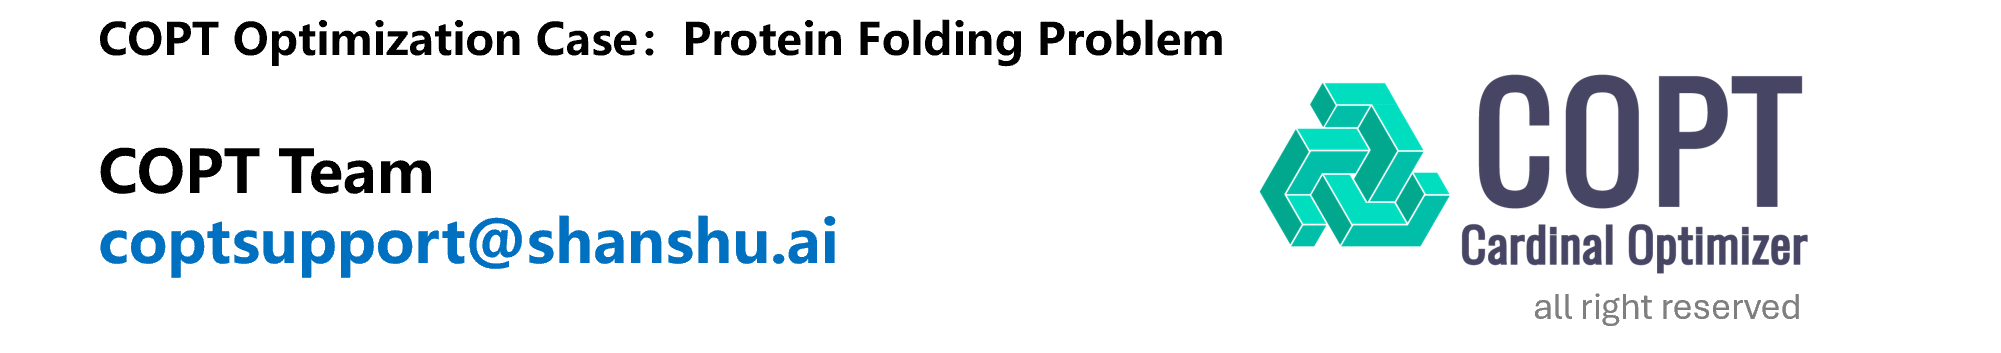

# Protein Folding Problem Code Implementation

## Steps to Model and Solve Protein Folding Problem Using COPT

1. **Import COPT-Python API** `coptpy`

2. **Add Model Data**
    - Import length of the chain and the position of hydrophobic amino acids

3. **Create the COPT Environment and COPT Model**

4. **Add three core components of COPT Model**
    - **Add Decision Variables**：
        - Define binary variable $edge_{i,j}$ to indicate whether each pair of hydrophobic amino acids (i, j) are paired
        - Define binary variable fold_(i) to indicate whether folding occurs between amino acids at indices $i$ and $i + 1$
    - **Set Objective Function**：Maximize number of pairing;
    - **Add Constraints**：
        - The number of other amino acids between paired amino acids must be even, and folding must occur at position $\frac{i + j - 1}{2}$
        - Between paired amino acids, folding cannot occur at any position other than $\frac{i + j - 1}{2}$ 

5. **Solve**

6. View and interpret the **results**

## Import COPT-Python API

In [4]:
import coptpy as cp
from coptpy import COPT

import matplotlib.pyplot as plt

## Add Model Data

In [6]:
# Import length of the chain
len_chain = 50
# len_chain = 27

# Import specific positions of known hydrophobic amino acids
# Note: The following is another set of data. Please use both sets together.
hydrophobic = [2, 4, 5, 6, 11, 12, 17, 20, 21, 25, 27, 28, 30, 31, 33, 37, 44, 46]
# hydrophobic = [2, 3, 4, 6, 9, 11, 14, 16, 19, 22, 23, 26]

# Turn the number into index
hydrophobic = [i - 1 for i in hydrophobic]

# Get the number of hydrophobic amino acids
num_hydrophobic = len(hydrophobic)

# Preprocess the edges of variables
pair_hydrophobic = [(hydrophobic[i], hydrophobic[j]) for i in range(num_hydrophobic) for j in range(i + 2, num_hydrophobic)]

# Get the number of the potentiallu available pairs
num_pair = len(pair_hydrophobic)

## Create the COPT Environment and COPT Model

In [8]:
env = cp.Envr()
model = env.createModel()

Cardinal Optimizer v8.0.5. Build date May 30 2026
Copyright Cardinal Operations 2026. All Rights Reserved



## Add three core components of COPT Model

### Add Decision Variables
1. Add a binary variable for each pair of hydrophobic amino acids to indicate whether they are paired
$$
    \text{edge}_{i, j} = \begin{cases}
        1, & \text{Amino acids at positions $i$ and $j$ are paired} \\
        0, & \text{Amino acids at positions $i$ and $j$ are not paired}
    \end{cases}
$$


In [10]:
edge = model.addVars(pair_hydrophobic, vtype=COPT.BINARY, nameprefix='edge')

2. Add a binary variable for each amino acid in the chain except the last one to indicate whether folding occurs at that position
$$
    \text{fold}_i = \begin{cases}
        1, & \text{Folding occurs between positions $i$ and $i + 1$} \\
        0, & \text{No folding occurs between positions $i$ and $i + 1$}
    \end{cases}
$$

In [12]:
fold = model.addVars(len_chain - 1, vtype=COPT.BINARY, nameprefix='fold')

### Set Objective Function
The objective is to maximize the total number of pairings
$$
    \max \, \sum_{(i, j)}\text{edge}_{i, j}
$$

In [14]:
model.setObjective(cp.quicksum(edge), sense=COPT.MAXIMIZE)

### Add Constraints
1. The number of other amino acids between paired amino acids must be even, and folding must occur at position $\frac{i + j - 1}{2}$
$$
\begin{cases}
    \text{edge}_{i, j} = 0, & \text{if $\frac{i + j - 1}{2}$ is not an integer} \\
    \text{edge}_{i, j} \leq \text{fold}_{\frac{i + j - 1}{2}}, & \text{if $\frac{i + j - 1}{2}$ is an integer}
\end{cases}
$$

In [16]:
for i in range(len_chain):
    for j in range(i + 2, len_chain):
        if (i, j) not in pair_hydrophobic:
            continue
        if (j + i - 1) / 2 != int((j + i - 1) / 2):
            model.addConstr(edge[(i, j)] == 0)
        else:
            model.addConstr(edge[(i, j)] <= fold[int((i + j - 1) / 2)])
                

2. Between paired amino acids, folding cannot occur at any position other than $\frac{i + j - 1}{2}$ 
$$
    \text{edge}_{i, j} + \text{fold}_{k} \leq 1, \, \forall \, k \in [i, j), k \neq \frac{i + j - 1}{2}
$$

In [18]:
for i in range(len_chain):
    for j in range(i + 2, len_chain):
        if (i, j) not in pair_hydrophobic:
            continue
        for u in range(i, j):
            if u != (i + j - 1) / 2:
                model.addConstr(edge[(i, j)] + fold[u] <= 1)

## Solve

In [20]:
model.solve()

Model fingerprint: e8a32521

Using Cardinal Optimizer v8.0.5 on Windows (22H2 Build 19045 - x86_64)
The CPU model is Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz
Hardware has 4 physical cores and 8 logical cores. Using instruction set X86_AVX2 (10)
Maximizing a MIP problem

The original problem has:
    2468 rows, 185 columns and 4871 non-zero elements
    185 binaries

Starting the MIP solver with 8 threads and 32 tasks

Presolving the problem

The presolved problem has:
    832 rows, 90 columns and 2055 non-zero elements
    90 binaries

Problem info:
    Range of matrix coefficients:    [1e+00,1e+00]
    Range of rhs coefficients:       [1e+00,1e+00]
    Range of bound coefficients:     [1e+00,1e+00]
    Range of cost coefficients:      [1e+00,1e+00]
    Density of cost:                     73.3%

     Nodes    Active  LPit/n  IntInf     BestBound  BestSolution     Gap   Time
         0         1      --       0  6.600000e+01            --     Inf  0.10s
H        0         1      --   

## Retrieve Results

Number of the maximum pairing is 8.0


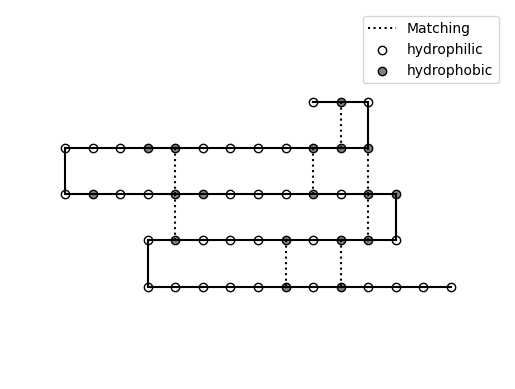

In [22]:
if model.status == COPT.OPTIMAL:
    print(f'Number of the maximum pairing is {round(model.objval, 0)}')
    variables = model.getVars()
    x = 0
    y = 0
    dir = 1
    min_x = 0
    max_x = 0
    min_y = 0
    max_y = 0
    coordinate = []
    # Calculate the coordinate
    for i in range(len_chain):
        coordinate.append([x, y])
        max_x = max(max_x, x)
        min_x = min(min_x, x)
        max_y = max(max_y, y)
        min_y = min(min_y, y)
        # Calculate the next point
        if i != len_chain - 1 and variables[i + num_pair].x >= 0.9:
            y -= 1
            dir *= -1
        else:
            x += dir
        # Draw segment of the origin chain
        if i != len_chain - 1:
            plt.plot([coordinate[-1][0], x], [coordinate[-1][1], y], linestyle='-', color='black')
    # Draw new segment
    index = 0
    mark = 1
    for item in pair_hydrophobic:
        if variables[index].x >= 0.9:
            if mark == 1:
                plt.plot([coordinate[item[0]][0], coordinate[item[1]][0]],
                        [coordinate[item[0]][1], coordinate[item[1]][1]], linestyle=':', color='black', label='Matching')
                mark = 0
            else:
                plt.plot([coordinate[item[0]][0], coordinate[item[1]][0]],
                        [coordinate[item[0]][1], coordinate[item[1]][1]], linestyle=':', color='black')
        index += 1
    # Draw points
    mark_0 = 1
    mark_1 = 1
    for i in range(len_chain):
        if i in hydrophobic:
            if mark_0 == 1:
                plt.scatter(coordinate[i][0], coordinate[i][1], facecolors='gray', edgecolors='black', label='hydrophobic')
                mark_0 = 0
            else:
                plt.scatter(coordinate[i][0], coordinate[i][1], facecolors='gray', edgecolors='black')
        else:
            if mark_1 == 1:
                plt.scatter(coordinate[i][0], coordinate[i][1], facecolors='white', edgecolors='black', label='hydrophilic')
                mark_1 = 0
            else:
                plt.scatter(coordinate[i][0], coordinate[i][1], facecolors='white', edgecolors='black')
    plt.axis('off')
    plt.xlim(min_x - 2, max_x + 2)
    plt.ylim(min_y - 2, max_y + 2)
    plt.legend()
    plt.show()
else:
    print('Fail to find the optimal solution.')